In [125]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

# from jax.numpy import einsum

# for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import (
    paper_style,
    paper_style_small,
    revtex_textwidth,
    revtex_columnwidth,
    set_size,
)
from blochK.observable import conductivity_orbital_resolved


import plot_funcs as pf

import sys, os


from alter_surf.utils3D import projector2layer

import pickle

matplotlib.rcParams.update(
    {
        "font.size": 7,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.9
aps_halfwidth = 3.4

In [ ]:
rng = np.random.default_rng(seed=0)


sigma = [
    np.eye(2),
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]]),
]


# order is spin, layer, sublattice

sym = np.kron(np.kron(sigma[2], sigma[0]), sigma[1])


def V(pm, on_site, rng):

    # make m
    m = 1 - 2 * rng.random([8, 8])
    m = 0.5 * (m + m.T)

    # make it symmetric
    m_plus = m + sym @ m @ sym
    m_minus = m - sym @ m @ sym
    matrix = m_plus + 1j * m_minus
    if pm == -1:
        matrix = (-1j * matrix).conj()

    if on_site:
        sigma_projector = np.kron(np.kron(np.ones((2, 2)), np.ones((2, 2))), sigma[1])
    else:
        sigma_projector = np.kron(np.kron(np.ones((2, 2)), np.ones((2, 2))), sigma[0])
    return matrix * sigma_projector


def surface_perturbation_func(strength_onsite, strength_nn, rng):
    v_matrices = [
        V(1, True, rng),
        V(1, False, rng),
        V(1, False, rng),
        V(-1, False, rng),
        V(-1, False, rng),
    ]

    def func(kx, ky):
        sk_p = np.sin((kx + ky) / 2) + np.sin((kx - ky) / 2)
        ck_p = np.cos((kx + ky) / 2) + np.cos((kx - ky) / 2)
        sk_m = np.sin((kx + ky) / 2) - np.sin((kx - ky) / 2)
        ck_m = np.cos((kx + ky) / 2) - np.cos((kx - ky) / 2)

        return strength_onsite * v_matrices[0] + strength_nn * (
            sk_p * v_matrices[1]
            + ck_p * v_matrices[2]
            + sk_m * v_matrices[3]
            + ck_m * v_matrices[4]
        )

    random_k = rng.uniform(0, 2 * np.pi, size=2)
    h1 = func(random_k[0], random_k[1])
    h2 = func(random_k[0], -random_k[1])
    assert np.all(
        h1 == sym @ h2.conj() @ sym
    ), "Perturbation does not satisfy symmetry constraint"

    return func


ham = surface_perturbation_func(1, 1, rng)

_IncompleteInputError: incomplete input (835364592.py, line 71)

define the two models


In [ ]:
# Drumhead Model
drumhead_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1)
Drumhead_2D = pf.slab_ham({"len_z": 31} | drumhead_params)


# Weyl Model
weyl_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1, dtpp=0.2)
Weyl_2D = pf.slab_ham({"len_z": 31} | weyl_params)


base_models_2D = [Drumhead_2D, Weyl_2D]
base_model_names = ["Drumhead", "Weyl"]

In [ ]:
# make the perturbations
def symres_perturb_function(len_z, rng, 

(124, 124, 10)

define the k space paths for everything


In [ ]:
# define spectral paths
n_k_2d_path = 100
n_k_2d_path = 20


drum_weyl_points = np.array([[0, 1], [0, 0], [1, 0], [0, 1], [1, 1], [0, 0]])
drum_weyl_labels = [r"Y", r"$\Gamma$", r"X", r"Y", r"M", r"$\Gamma$"]
drum_weyl_path = pf.make_path(drum_weyl_points, n_k_2d_path)
drum_weyl_path_positions = np.linspace(
    0, len(drum_weyl_path), len(drum_weyl_labels)
).astype(int)

paths = [drum_weyl_path, drum_weyl_path]
path_labels = [drum_weyl_labels, drum_weyl_labels]
path_positions = [
    drum_weyl_path_positions,
    drum_weyl_path_positions,
]

# define 2d slice k grids
n_k_grid = 101
n_k_grid = 31
spillover = 0.25
k_slice = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)
KX_slice, KY_slice = np.meshgrid(k_slice, k_slice)

In [ ]:
# solve paths
energies_path = []
states_path = []

for model, path in zip(models_2D, paths):
    energies, states = model.diagonalize(*path.T)
    energies_path.append(energies)
    states_path.append(states)

# solve 2D grids
energies_grid = []
states_grid = []

for model in models_2D:
    energies, states = model.diagonalize(KX_slice, KY_slice)
    energies_grid.append(energies)
    states_grid.append(states)

In [ ]:
from tqdm import tqdm

# make spectral walk functions
eta = 4e-2

spec_e_vals = []
spec_boundary_path = []
spec_bulk_path = []

for model, states, energies in zip(tqdm(models_2D), states_path, energies_path):

    e_vals = np.linspace(np.min(energies), np.max(energies), 200)
    specs_boundary_walk = pf.make_spectral_functions(
        model, [0], states, energies, e_vals, eta
    )
    specs_bulk_walk = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, e_vals, eta
    )

    colors_bulk_walk, colors_boundary_walk = pf.normalize_and_find_colours(
        specs_bulk_walk, specs_boundary_walk, 0.7
    )
    spec_e_vals.append(e_vals)
    spec_boundary_path.append(colors_boundary_walk)
    spec_bulk_path.append(colors_bulk_walk)

del specs_bulk_walk, specs_boundary_walk

100%|██████████| 2/2 [00:07<00:00,  3.94s/it]


In [ ]:
# make slice spectral functions

fermi_level = np.array([0])
eta = 2e-2

spec_boundary_grid = []
spec_bulk_grid = []

for model, states, energies in zip(tqdm(models_2D), states_grid, energies_grid):
    specs_boundary_slice = pf.make_spectral_functions(
        model, [0], states, energies, fermi_level, eta
    )
    specs_bulk_slice = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, fermi_level, eta
    )
    colors_bulk_slice, colors_boundary_slice = pf.normalize_and_find_colours(
        specs_bulk_slice, specs_boundary_slice, 0.5
    )
    spec_boundary_grid.append(colors_boundary_slice)
    spec_bulk_grid.append(colors_bulk_slice)

del specs_bulk_slice, specs_boundary_slice

100%|██████████| 2/2 [00:01<00:00,  1.61it/s]


In [ ]:
# make conductivities

from alter_surf.utils_CuMnAs import get_conductivity_layer_resolved as gcl_drum_weyl

gcl = [gcl_drum_weyl, gcl_drum_weyl]

layers = []
conds = []
spin_conds = []

for model, g in zip(tqdm(models_2D), gcl):
    l, c, s = g(model, Lk=50)
    layers.append(l)
    conds.append(c)
    spin_conds.append(s)

del l, c, s, gcl

100%|██████████| 2/2 [01:09<00:00, 34.64s/it]


In [ ]:
# collate all results

models = {"models_2D": models_2D}

# spectral walks
spec_walks = {
    "paths": paths,
    "path_labels": path_labels,
    "path_positions": path_positions,
    "spec_e_vals": spec_e_vals,
    "spec_boundary_path": spec_boundary_path,
    "spec_bulk_path": spec_bulk_path,
}

# spectral grids
spec_grids = {
    "KX_slice": KX_slice,
    "KY_slice": KY_slice,
    "spec_boundary_grid": spec_boundary_grid,
    "spec_bulk_grid": spec_bulk_grid,
}

# conductivities
conductivities = {"layers": layers, "conds": conds, "spin_conds": spin_conds}


# save all results
with open("figure_perturbation.pkl", "wb") as f:
    pickle.dump(
        {
            "models": models,
            "spec_walks": spec_walks,
            "spec_grids": spec_grids,
            "conductivities": conductivities,
        },
        f,
    )

In [ ]:
# load all results

with open("figure_perturbation.pkl", "rb") as f:
    r = pickle.load(f)
    models = r["models"]
    spec_walks = r["spec_walks"]
    spec_grids = r["spec_grids"]
    conductivities = r["conductivities"]

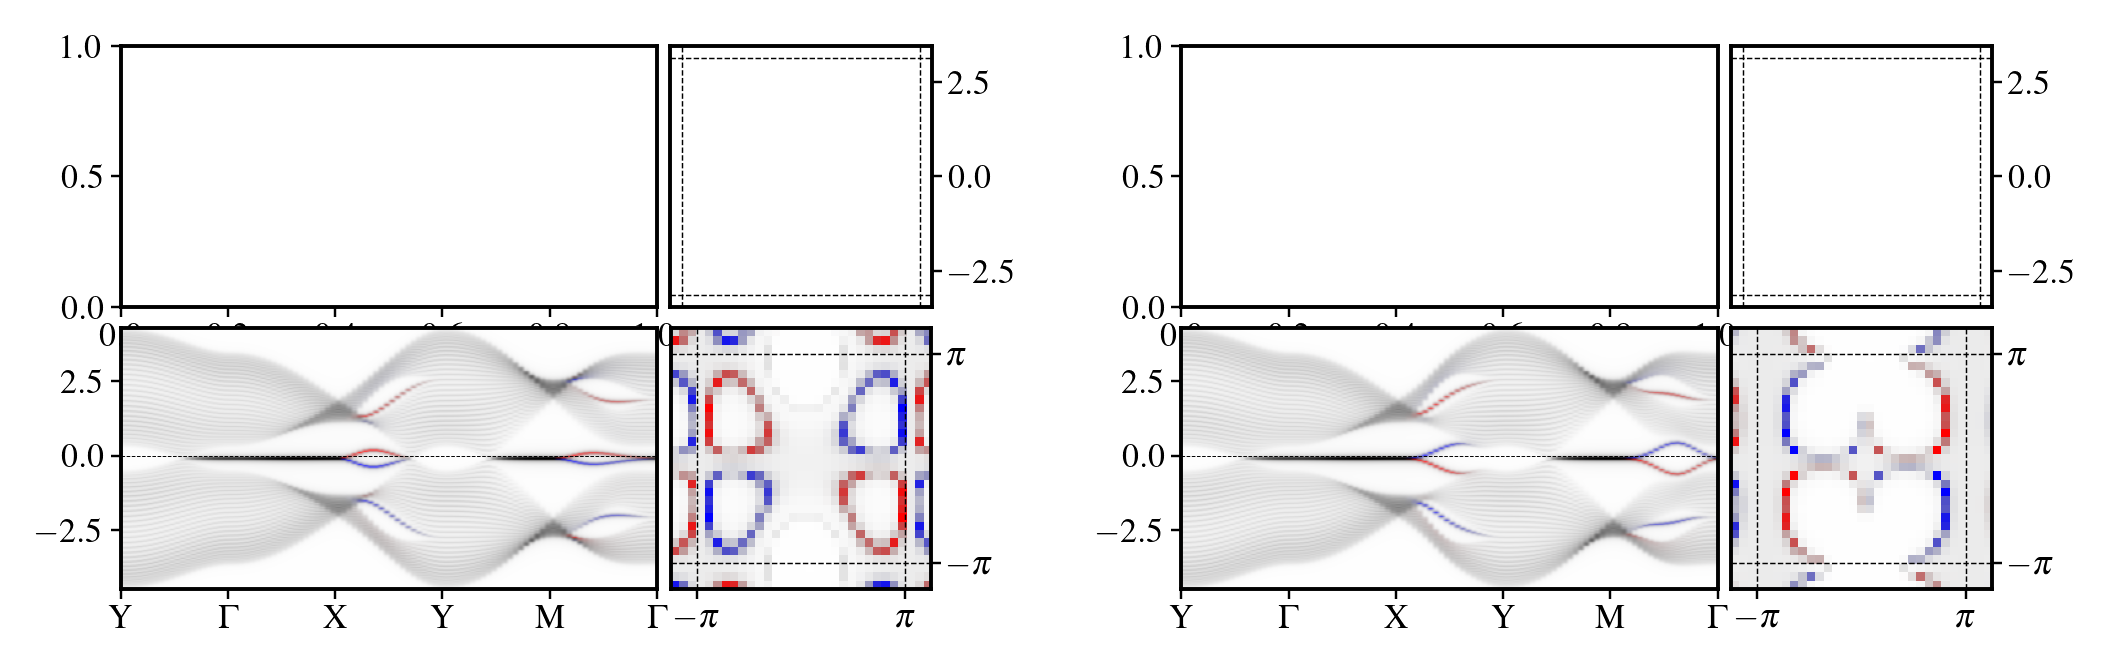

In [ ]:
subplot_arrangement = """
ccccdd.eeeeff
ccccdd.eeeeff
ccccdd.eeeeff
.............
hhhhii.jjjjkk
hhhhii.jjjjkk
hhhhii.jjjjkk
"""
gap1 = 1.3
gap2 = 1.8
wspace = 0.1
hspace = 0.0
height_ratios = [1, 1, 1, 0.25, 1, 1, 1]
width_ratios = [1] * 6 + [gap2] + [1] * 6
fudge_factor = 0.7

height = np.sum(height_ratios)
width = np.sum(width_ratios) + wspace * (len(width_ratios) - 1)
aps_figheight = fudge_factor * aps_figwidth * height / width

fig = plt.figure(figsize=(aps_figwidth, aps_figheight), dpi=350)
axd = fig.subplot_mosaic(
    subplot_arrangement,
    gridspec_kw={"wspace": wspace, "hspace": hspace},
    width_ratios=width_ratios,
    height_ratios=height_ratios,
)


################### boundary path ###################
axd["h"].imshow(
    spec_walks["spec_boundary_path"][0],
    extent=(
        0,
        len(spec_walks["paths"][0]),
        spec_walks["spec_e_vals"][0][0],
        spec_walks["spec_e_vals"][0][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["h"].set_xticks(spec_walks["path_positions"][0], spec_walks["path_labels"][0])
# axd["h"].tick_params(axis="y", direction="in", labelleft=False)

axd["j"].imshow(
    spec_walks["spec_boundary_path"][1],
    extent=(
        0,
        len(spec_walks["paths"][1]),
        spec_walks["spec_e_vals"][1][0],
        spec_walks["spec_e_vals"][1][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["j"].set_xticks(spec_walks["path_positions"][1], spec_walks["path_labels"][1])
# axd["j"].tick_params(axis="y", direction="in", labelleft=False)


################### boundary grid ###################
axd["i"].imshow(
    np.swapaxes(spec_grids["spec_boundary_grid"][0], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)

axd["i"].set_xticks([-np.pi, np.pi])
axd["i"].set_yticks([-np.pi, np.pi])
axd["i"].set_yticklabels(["$-\\pi$", "$\\pi$"])
axd["i"].set_xticklabels(["$-\\pi$", "$\\pi$"])

axd["k"].imshow(
    np.swapaxes(spec_grids["spec_boundary_grid"][1], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)


axd["k"].set_xticks([-np.pi, np.pi])
axd["k"].set_yticks([-np.pi, np.pi])
axd["k"].set_yticklabels(["$-\\pi$", "$\\pi$"])
axd["k"].set_xticklabels(["$-\\pi$", "$\\pi$"])


# for a in axd:
#     axd[a].tick_params(axis="y", direction="in")
#     axd[a].tick_params(axis="x", direction="in")

for a in (axd["d"], axd["f"], axd["i"], axd["k"]):
    a.axhline(-np.pi, color="k", ls="--", lw=0.3)
    a.axhline(np.pi, color="k", ls="--", lw=0.3)
    a.axvline(-np.pi, color="k", ls="--", lw=0.3)
    a.axvline(np.pi, color="k", ls="--", lw=0.3)

    a.tick_params(
        left=False,
        labelleft=False,
        right=True,
        labelright=True,
    )
for a in (axd["d"], axd["f"]):
    a.tick_params(
        bottom=False,
        labelbottom=False,
    )

for a in (axd["c"], axd["e"], axd["h"], axd["j"]):
    a.axhline(0, color="k", ls="--", lw=0.2)

for a in axd:
    axd[a].tick_params(length=2, width=0.5, pad=1.3)

# plt.savefig("perturbation.png", dpi=350, bbox_inches="tight", transparent=True)